# Correlations

In [1]:
import pandas as pd

temp = pd.read_parquet("../../../data/clean/Yashaswi/Final_Clean/temp_2015.parquet")
print(temp.head())

  Climate ID       Date  Max Temp (°C)  Min Temp (°C)  Mean Temp (°C)  \
0    8204020 2021-09-11           18.7            8.7            13.7   
1    8204020 2021-09-12           22.4            9.8            16.1   
2    8204020 2021-09-13           20.8           11.0            15.9   
3    8204020 2021-09-14           17.2            6.9            12.1   
4    8204020 2021-09-15           20.2            5.7            13.0   

   Heat Deg Days (°C)  Cool Deg Days (°C)  
0                 4.3                 0.0  
1                 1.9                 0.0  
2                 2.1                 0.0  
3                 5.9                 0.0  
4                 5.0                 0.0  


In [2]:
precip = pd.read_parquet("../../../data/clean/Yashaswi/Final_Clean/precip_2015_2025.parquet")
print(precip.head())

    Climate ID  Date/Time  Total Rain (mm)  Total Snow (cm)  \
253    8204020 2021-09-11              NaN              NaN   
254    8204020 2021-09-12              NaN              NaN   
255    8204020 2021-09-13              NaN              NaN   
256    8204020 2021-09-14              NaN              NaN   
257    8204020 2021-09-15              NaN              NaN   

     Total Precip (mm)  Snow on Grnd (cm)  
253                0.0                NaN  
254                0.0                NaN  
255                0.1                NaN  
256                0.0                NaN  
257                0.0                NaN  


In [3]:
wind = pd.read_parquet("../../../data/clean/Yashaswi/Final_Clean/wind_2015_2025.parquet")
print(wind.head())

   wind_key Climate ID       Date  Dir of Max Gust (10s deg)  \
0    166313    840KN90 2015-01-01                       21.0   
1    166314    8200774 2015-01-01                       18.0   
2    166315    8404025 2015-01-01                       26.0   
3    166316    8401703 2015-01-01                       22.0   
4    166317    8206491 2015-01-01                       26.0   

   Spd of Max Gust (km/h)  
0                    44.0  
1                    33.0  
2                    56.0  
3                    35.0  
4                    48.0  


In [4]:
poll = pd.read_parquet("../../../data/clean/Yashaswi/DimPollutants/Pollutants2015_Parquet/")

poll.rename(columns={'NAPS ID': 'NAPS_ID'}, inplace=True)
print(poll.head())

   NAPS_ID       Date Pollutant  Year        C  AQI
0    10102 2015-01-01        CO  2015  0.19500  2.0
1    10102 2015-01-02        CO  2015  0.17750  2.0
2    10102 2015-01-03        CO  2015  0.17000  2.0
3    10102 2015-01-04        CO  2015  0.17750  2.0
4    10102 2015-01-05        CO  2015  0.16875  2.0


In [5]:
st = pd.read_csv("../../../data/clean/Yashaswi/Final_Clean/dim_station_clean.csv")
print(st.head())

   Longitude (x)  Latitude (y)    Station Name Climate ID  \
0         -64.51         44.83    AALDERSVILLE    8204020   
1         -54.00         47.31  ARGENTIA (AUT)    8400104   
2         -67.72         46.71       AROOSTOOK    8100300   
3         -65.47         43.45      BACCARO PT    8200255   
4         -56.07         48.97    BADGER (AUT)    8400301   

                    Province  
0                NOVA SCOTIA  
1  NEWFOUNDLAND AND LABRADOR  
2              NEW BRUNSWICK  
3                NOVA SCOTIA  
4  NEWFOUNDLAND AND LABRADOR  


In [6]:
naps = pd.read_csv("../../../data/clean/Yashaswi/Final_Clean/Dim_Station_NAPS.csv")
print(naps.head())

   NAPS_ID              Station_Name                      City  \
0    10102  WATER STREET POST OFFICE                ST. JOHN'S   
1    10401               MOUNT PEARL               MOUNT PEARL   
2    10501              ABITIBI SITE     GRAND FALLS - WINDSOR   
3    10601                 GOOSE BAY  HAPPY VALLEY - GOOSE BAY   
4    10602         MACPHERSON AVENUE              CORNER BROOK   

       Province/Territory_EN Province_Code  Latitude  Longitude  Status  \
0  NEWFOUNDLAND AND LABRADOR            NL  47.56038  -52.71147       1   
1  NEWFOUNDLAND AND LABRADOR            NL  47.50513  -52.79476       1   
2  NEWFOUNDLAND AND LABRADOR            NL  48.92696  -55.65966       1   
3  NEWFOUNDLAND AND LABRADOR            NL  53.30600  -60.36314       1   
4  NEWFOUNDLAND AND LABRADOR            NL  48.95224  -57.92207       1   

   Start_Date End_Date  
0  1988-07-31      NaN  
1  2002-05-04      NaN  
2  2004-05-17      NaN  
3  2005-03-09      NaN  
4  2009-07-14      NaN  


In [7]:
# --- TEMP ---
temp['Date'] = pd.to_datetime(temp['Date'])

# --- PRECIP ---
precip.rename(columns={'Date/Time': 'Date'}, inplace=True)
precip['Date'] = pd.to_datetime(precip['Date'])

# --- WIND ---
wind['Date'] = pd.to_datetime(wind['Date'])

# --- POLL ---
poll['Date'] = pd.to_datetime(poll['Date'])

In [11]:
temp.rename(columns={'Climate ID': 'Climate_ID'}, inplace=True)
precip.rename(columns={'Climate ID': 'Climate_ID'}, inplace=True)
wind.rename(columns={'Climate ID': 'Climate_ID'}, inplace=True)

In [12]:
import pandas as pd
import numpy as np

# Rename for clarity
climate_st = st[['Climate ID', 'Latitude (y)', 'Longitude (x)']].copy()
climate_st.columns = ['Climate_ID', 'lat_climate', 'lon_climate']

naps_st = naps[['NAPS_ID', 'Latitude', 'Longitude']].copy()
naps_st.columns = ['NAPS_ID', 'lat_naps', 'lon_naps']

In [13]:
from scipy.spatial.distance import cdist

# Compute distance matrix
dist_matrix = cdist(
    naps_st[['lat_naps', 'lon_naps']],
    climate_st[['lat_climate', 'lon_climate']],
    metric='euclidean'
)

# Get nearest climate index
nearest_idx = dist_matrix.argmin(axis=1)

# Map Climate ID
naps_st['Climate_ID'] = climate_st.iloc[nearest_idx]['Climate_ID'].values


In [14]:
poll = poll.merge(naps_st[['NAPS_ID', 'Climate_ID']], on='NAPS_ID', how='left')

In [15]:
poll_pivot = poll.pivot_table(
    index=['Date', 'Climate_ID', 'NAPS_ID'],   # ✅ INCLUDE THIS
    columns='Pollutant',
    values='C'
).reset_index()

In [16]:
# Convert dates
temp['Date'] = pd.to_datetime(temp['Date'])
precip['Date'] = pd.to_datetime(precip['Date'])
wind['Date'] = pd.to_datetime(wind['Date'])
poll_pivot['Date'] = pd.to_datetime(poll_pivot['Date'])

df = temp.merge(precip, on=['Date', 'Climate_ID'], how='inner') \
         .merge(wind, on=['Date', 'Climate_ID'], how='inner') \
         .merge(poll_pivot, on=['Date', 'Climate_ID'], how='inner')

In [17]:
cols = [
    'Mean Temp (°C)', 'Max Temp (°C)',
    'Total Rain (mm)', 'Total Snow (cm)', 'Total Precip (mm)',
    'Dir of Max Gust (10s deg)', 'Spd of Max Gust (km/h)'
] + list(poll_pivot.columns.drop(['Date', 'Climate_ID']))

df_corr = df[cols]

In [18]:
df_corr['wind_sin'] = np.sin(np.deg2rad(df_corr['Dir of Max Gust (10s deg)']))
df_corr['wind_cos'] = np.cos(np.deg2rad(df_corr['Dir of Max Gust (10s deg)']))

df_corr = df_corr.drop(columns=['Dir of Max Gust (10s deg)'])

In [19]:
df_corr = df_corr.fillna(0)  # or .dropna()
df_corr.head()

,Mean Temp (°C),Max Temp (°C),Total Rain (mm),Total Snow (cm),Total Precip (mm),Spd of Max Gust (km/h),NAPS_ID,CO,NO2,O3,PM10,PM2.5,SO2,wind_sin,wind_cos
0,-16.8,-10.1,0.0,0.0,0.3,43.0,10501,0.188571,10.0,0.035875,0.0,5.291667,0.5,0.469472,0.882948
1,-13.4,-9.5,0.0,0.0,8.5,32.0,10501,0.150000,2.0,0.037625,0.0,2.750000,0.4,0.438371,0.898794
2,-4.6,1.1,0.0,0.0,3.2,56.0,10501,0.196250,9.0,0.034333,0.0,3.375000,0.9,0.358368,0.933580
3,-11.5,-6.5,0.0,0.0,0.0,50.0,10501,0.156667,1.0,0.035250,0.0,1.875000,0.8,0.374607,0.927184
4,-12.7,1.6,0.0,0.0,8.2,61.0,10501,0.283750,12.0,0.039875,0.0,8.083333,0.8,0.292372,0.956305


In [20]:
corr_matrix = df_corr.corr()

print(corr_matrix)

                        Mean Temp (°C)  Max Temp (°C)  Total Rain (mm)  \
Mean Temp (°C)                1.000000       0.969483         0.053440   
Max Temp (°C)                 0.969483       1.000000         0.033371   
Total Rain (mm)               0.053440       0.033371         1.000000   
Total Snow (cm)              -0.038455      -0.049113         0.051310   
Total Precip (mm)             0.122525       0.067236         0.326042   
Spd of Max Gust (km/h)       -0.089402      -0.127036         0.180899   
NAPS_ID                      -0.070198      -0.026976        -0.137276   
CO                           -0.029860      -0.028786         0.003629   
NO2                          -0.190093      -0.166940        -0.021739   
O3                            0.035625       0.044547         0.006091   
PM10                          0.032221       0.032888        -0.011690   
PM2.5                         0.028200       0.040970        -0.008309   
SO2                           0.010485

In [22]:
summary = []

for prov, corr in province_corr.items():
    val = corr.loc['Mean Temp (°C)', 'PM2.5']  # example metric
    summary.append((prov, val))

summary = pd.DataFrame(summary, columns=['Province', 'Temp_PM25_corr'])
print(summary.sort_values('Temp_PM25_corr'))

Empty DataFrame
Columns: [Province, Temp_PM25_corr]
Index: []


In [23]:
import seaborn as sns

for prov in province_corr:
    plt.figure(figsize=(6,4))
    sns.heatmap(province_corr[prov], cmap='coolwarm', center=0)
    plt.title(prov)
    plt.show()

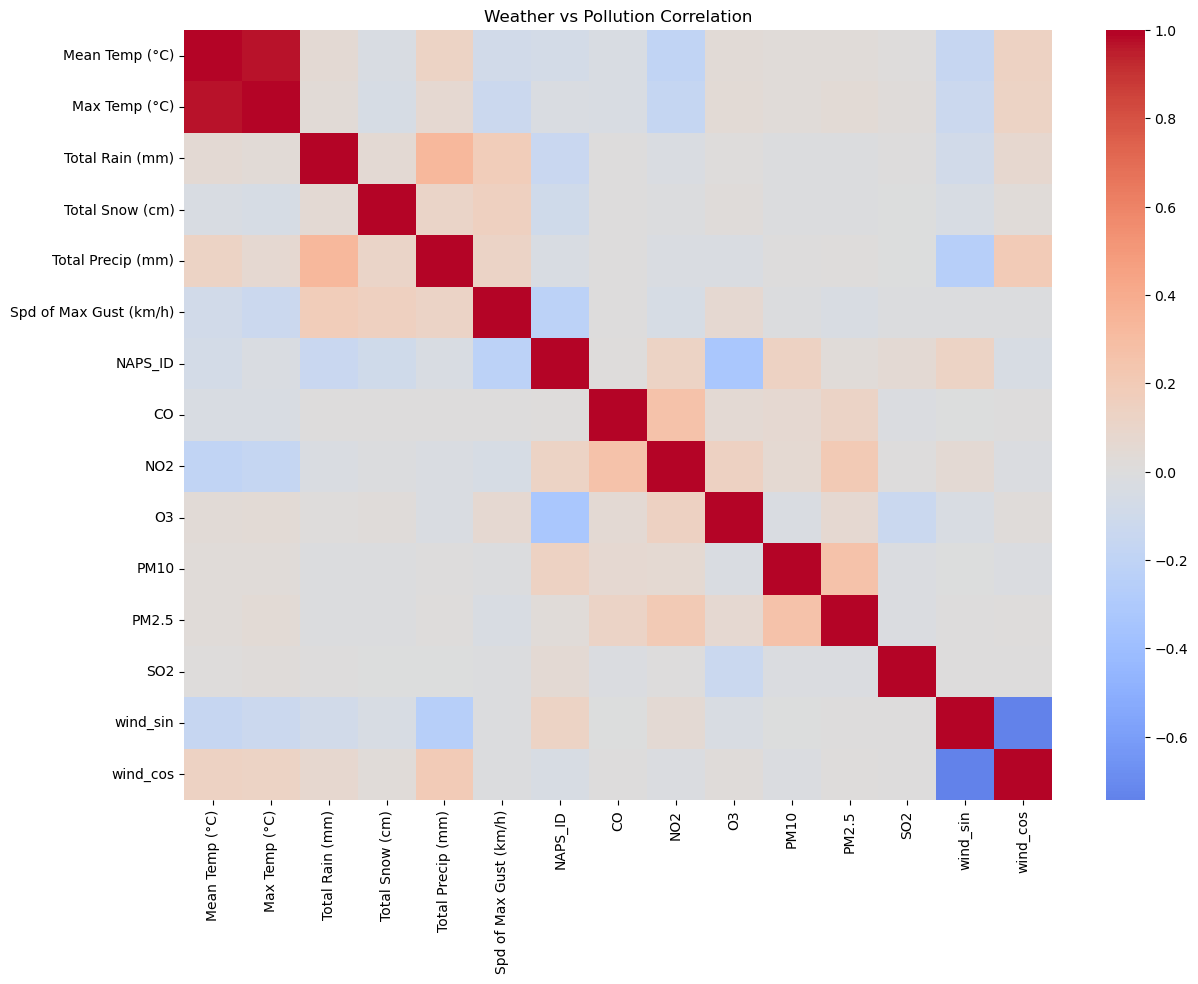

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Weather vs Pollution Correlation")
plt.show()


In [25]:
corr = df_corr.corr().abs()

# Pick top variables based on overall correlation strength
top_vars = corr.sum().sort_values(ascending=False).head(8).index

df_top = df_corr[top_vars]

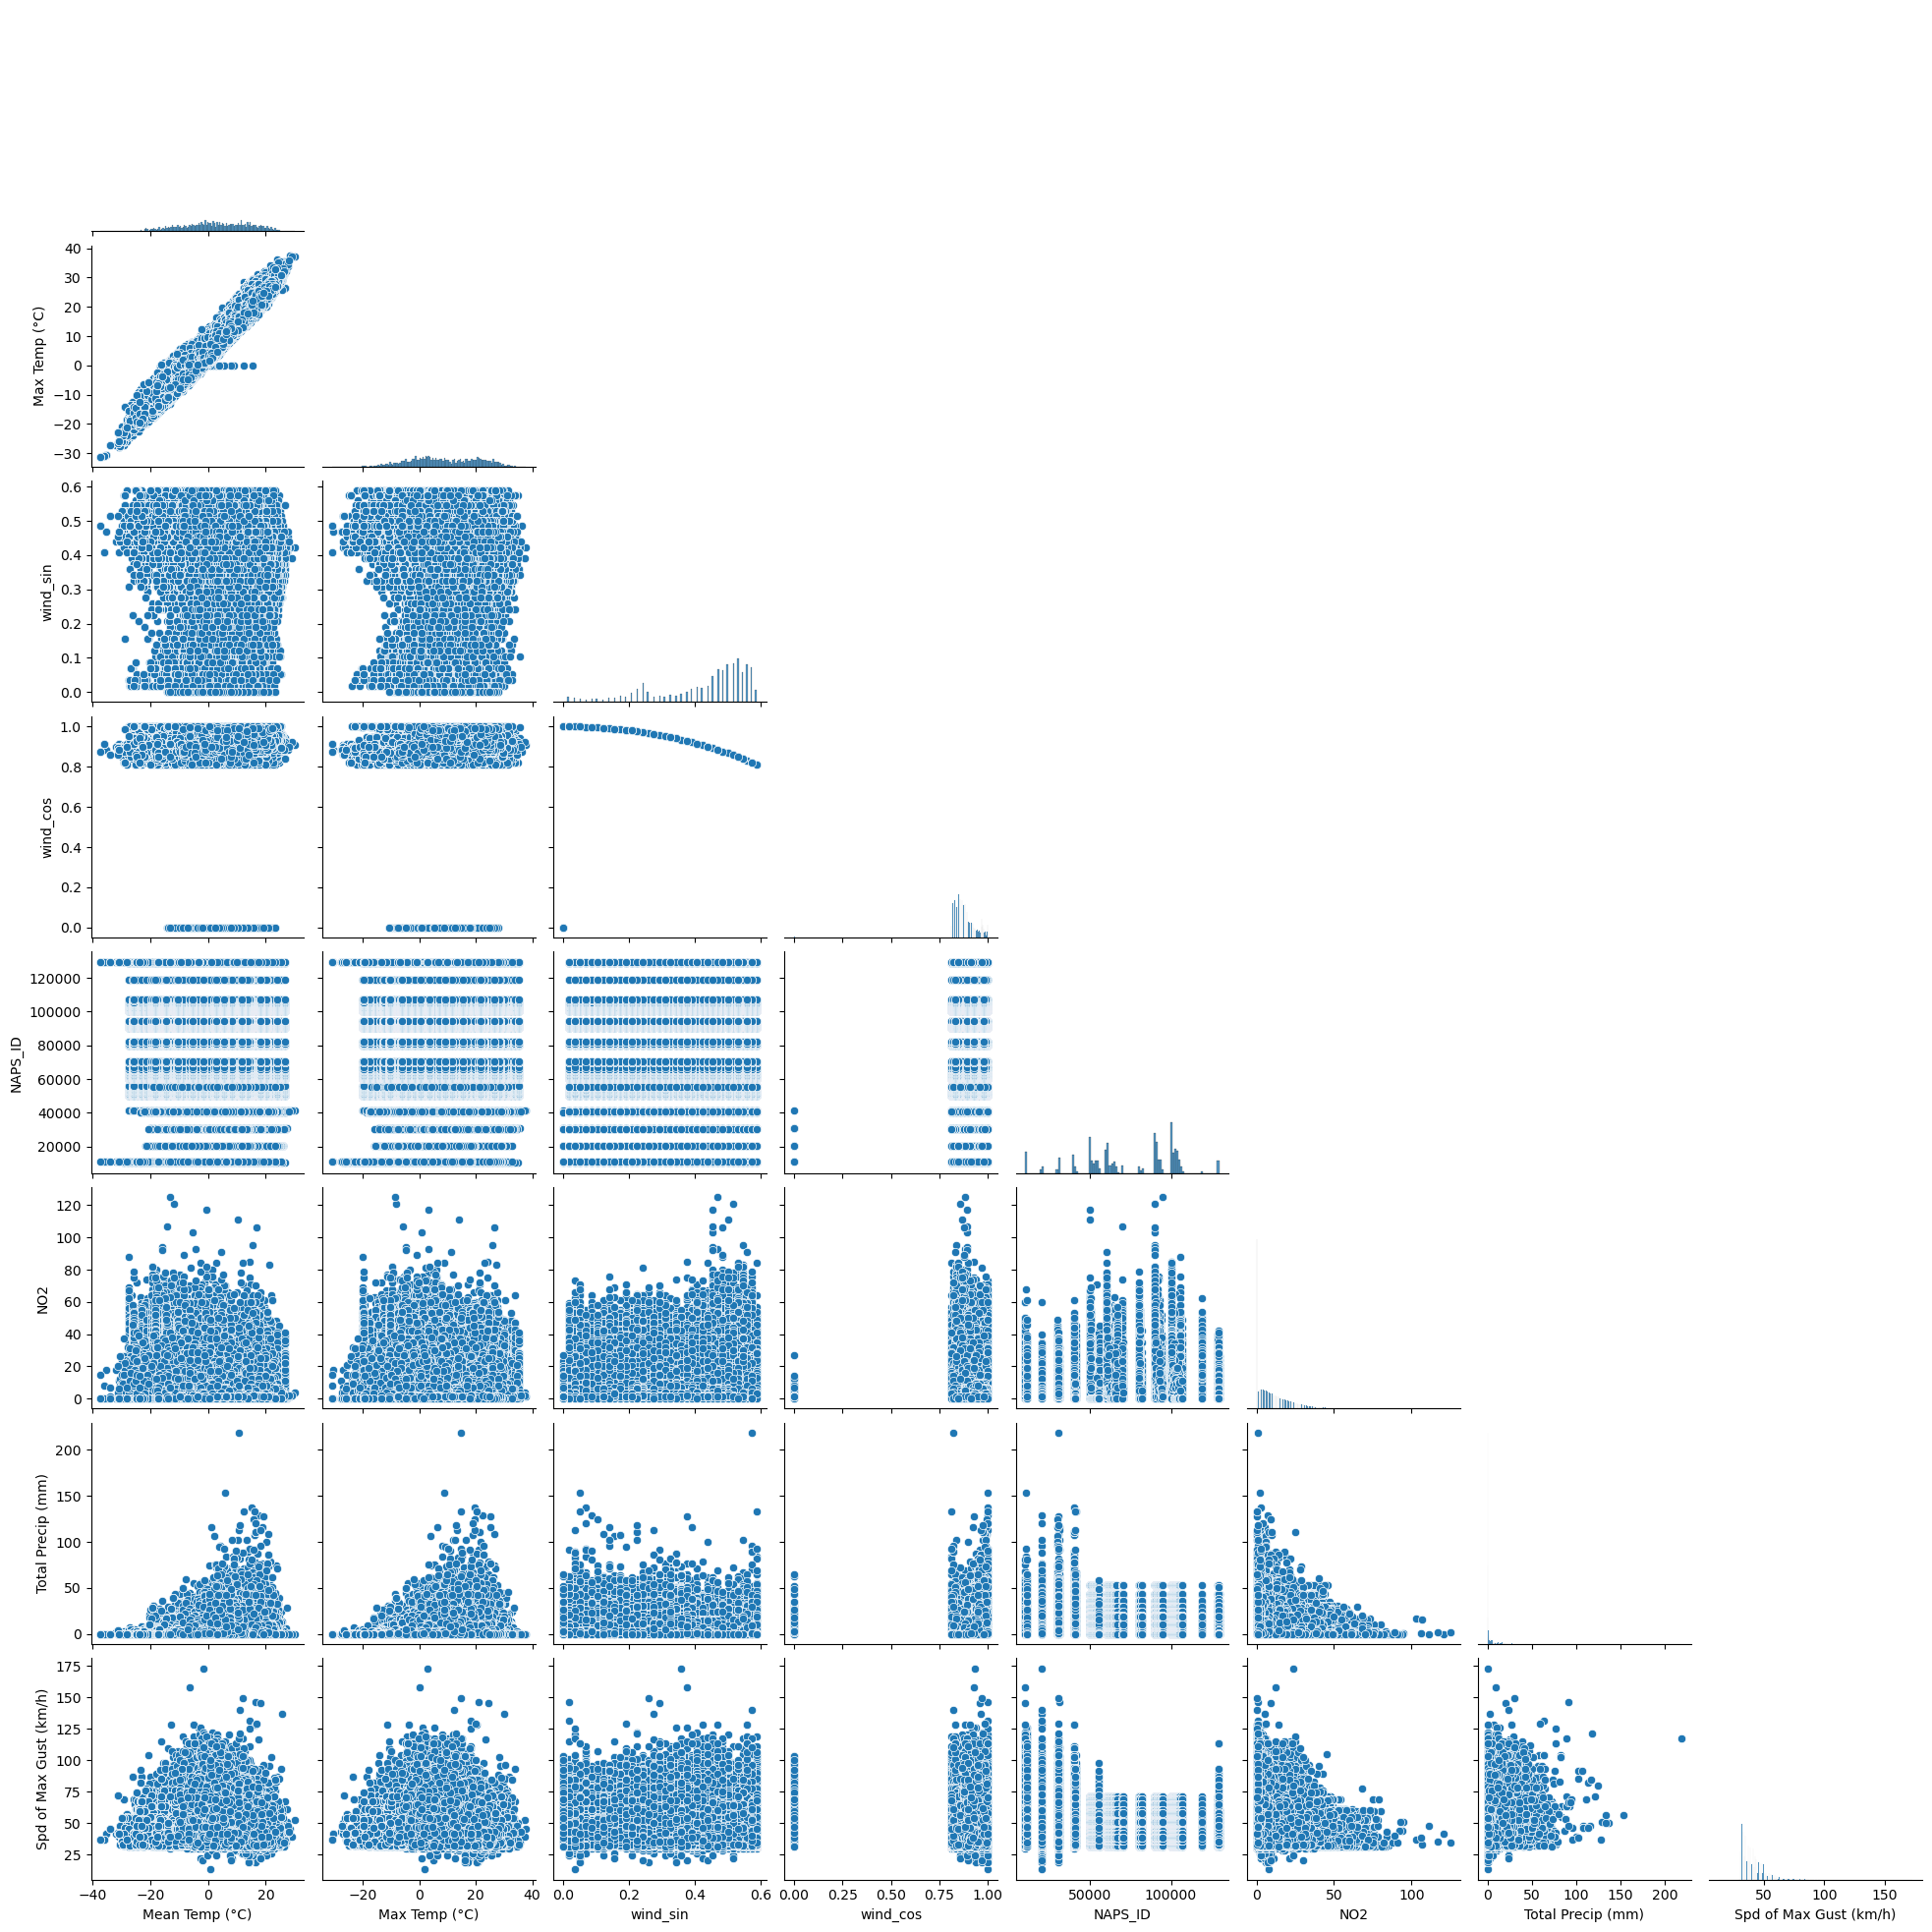

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df_top, corner=True)
plt.show()


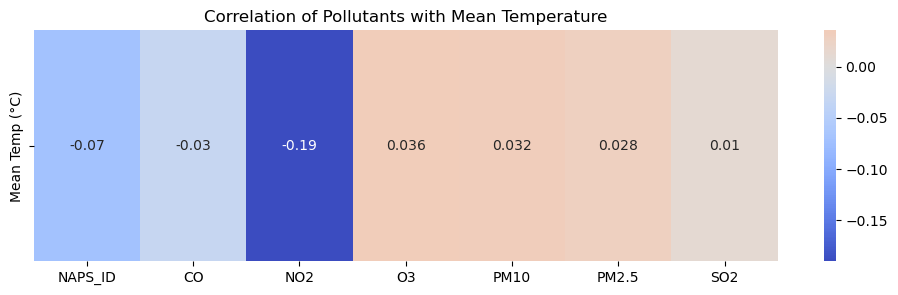

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select pollutants (auto-detect)
pollutants = [col for col in df_corr.columns 
              if col not in [
                  'Mean Temp (°C)', 'Max Temp (°C)',
                  'Total Rain (mm)', 'Total Snow (cm)',
                  'Total Precip (mm)', 'Spd of Max Gust (km/h)',
                  'wind_sin', 'wind_cos'
              ]]

# Compute correlations with Mean Temp
mean_temp_corr = df_corr[['Mean Temp (°C)'] + pollutants].corr()

# Keep only Mean Temp row
mean_temp_corr = mean_temp_corr.loc[['Mean Temp (°C)'], pollutants]

# Plot
plt.figure(figsize=(12, 3))
sns.heatmap(mean_temp_corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation of Pollutants with Mean Temperature")
plt.show()

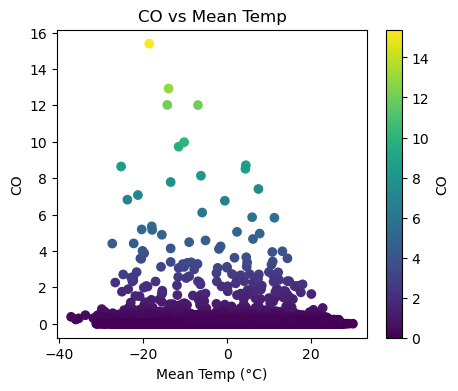

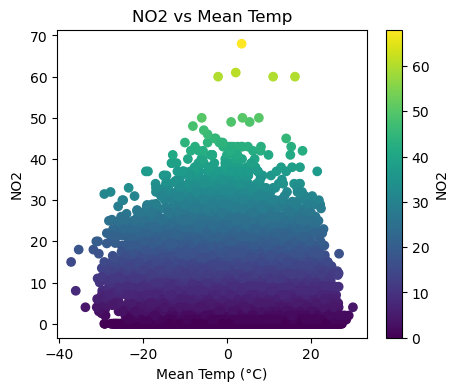

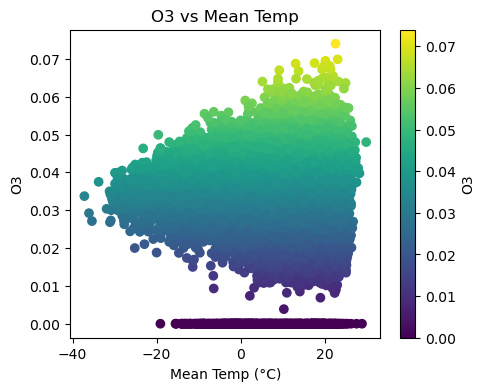

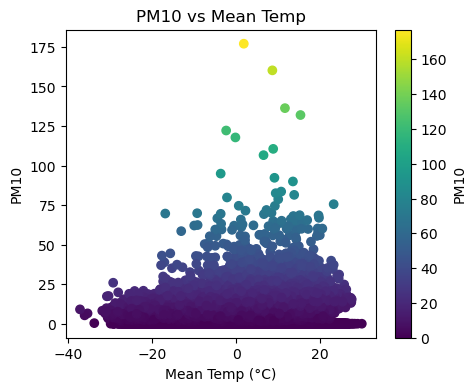

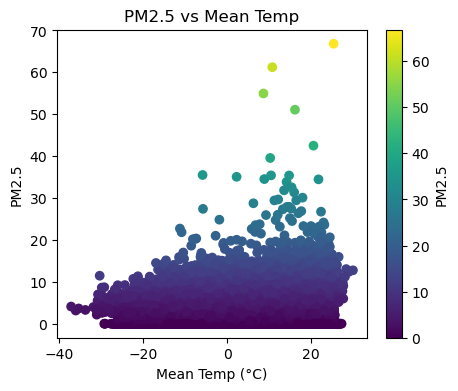

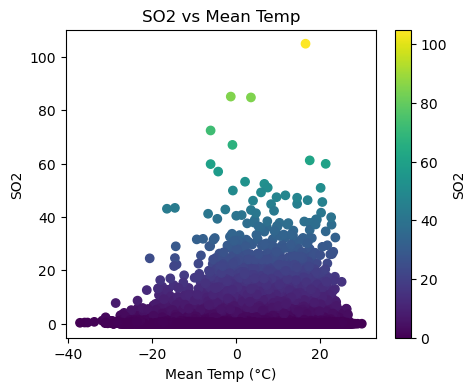

In [29]:
import matplotlib.pyplot as plt

for pol in pollutants:
    plt.figure(figsize=(5,4))
    plt.scatter(
        df_corr['Mean Temp (°C)'],
        df_corr[pol],
        c=df_corr[pol],
        cmap='viridis'
    )
    plt.colorbar(label=pol)
    plt.xlabel('Mean Temp (°C)')
    plt.ylabel(pol)
    plt.title(f'{pol} vs Mean Temp')
    plt.show()

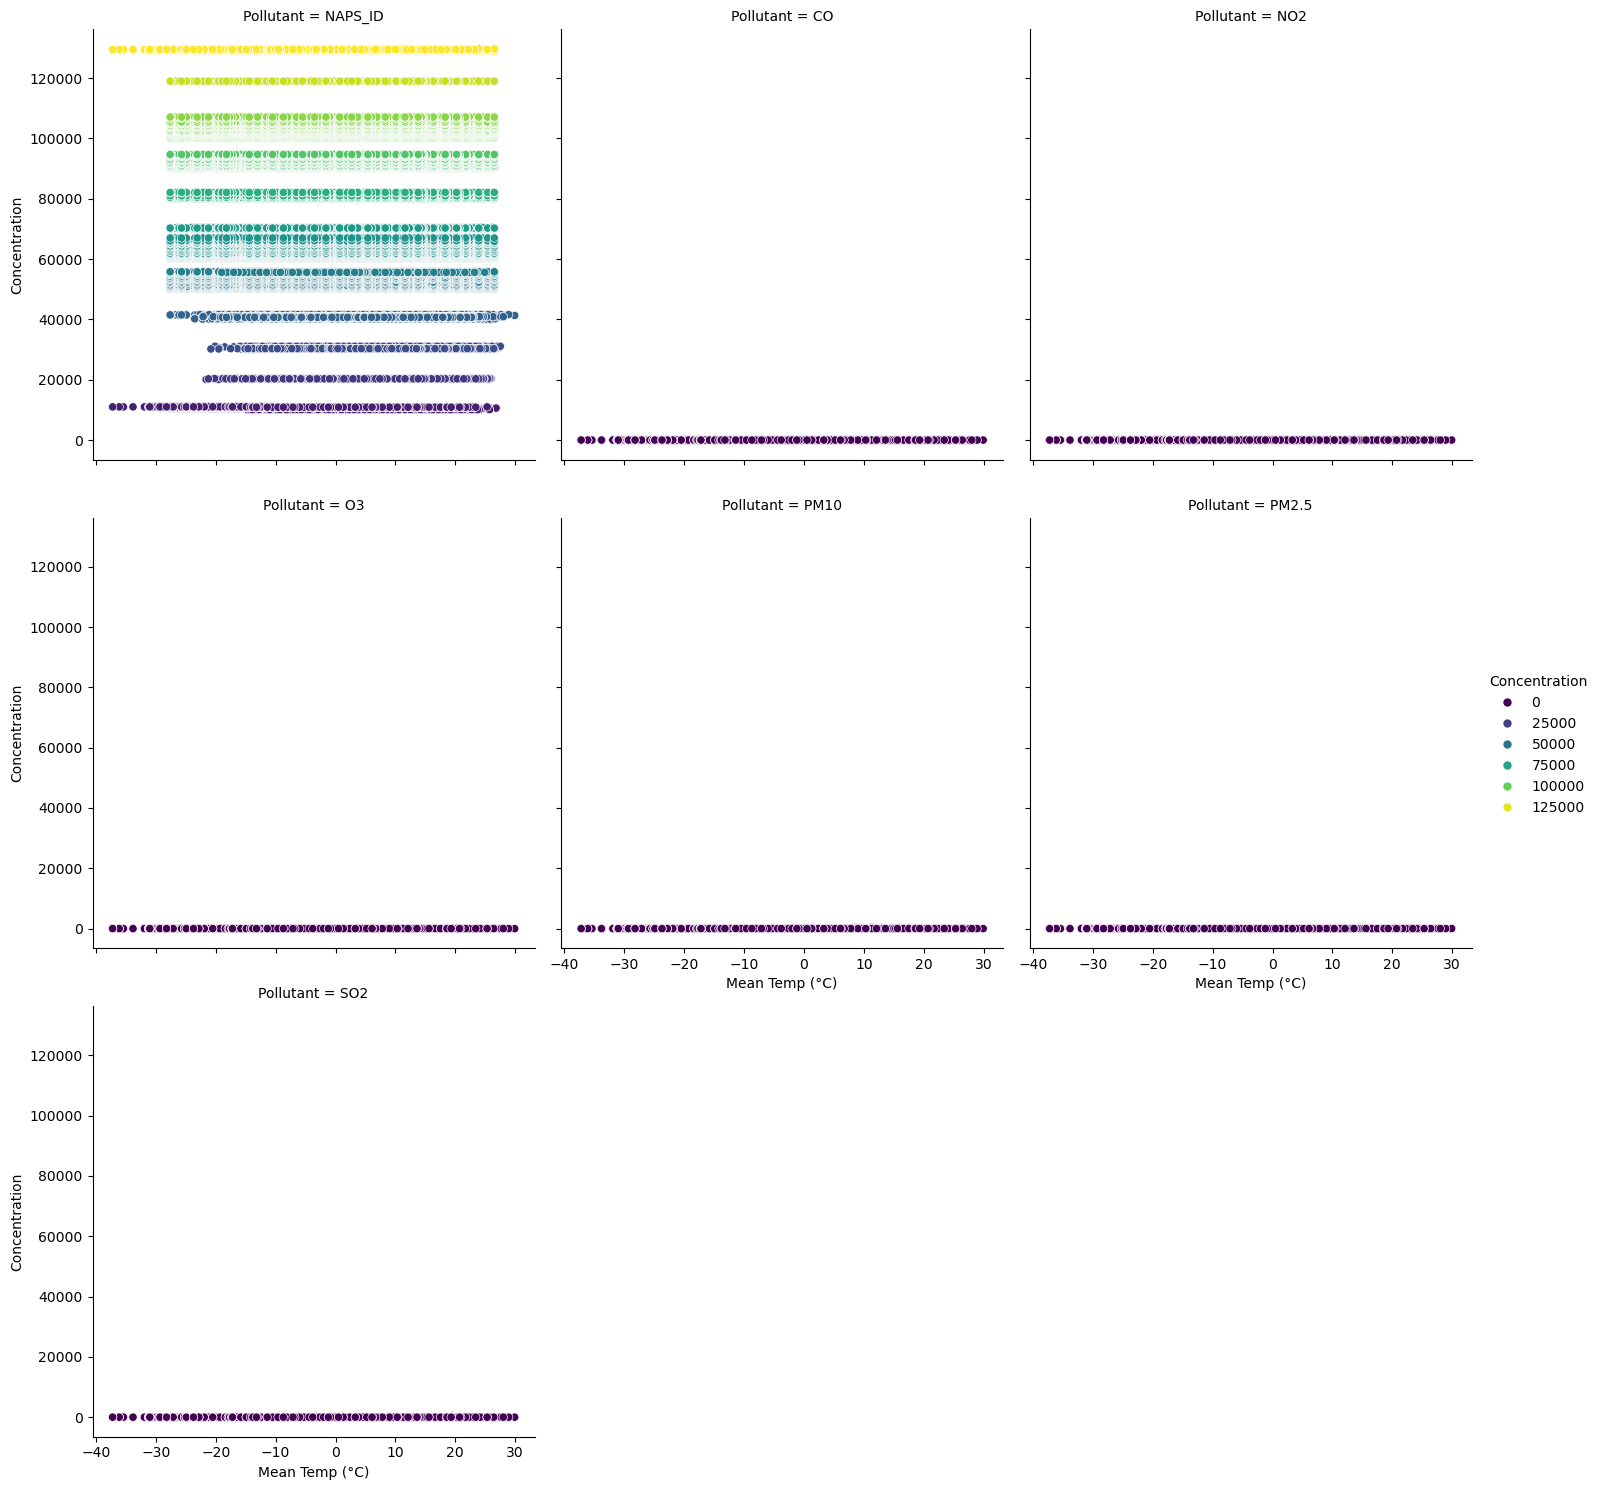

In [28]:
import seaborn as sns

# Melt data for plotting
df_melt = df_corr[['Mean Temp (°C)'] + pollutants].melt(
    id_vars='Mean Temp (°C)',
    var_name='Pollutant',
    value_name='Concentration'
)

# Plot
sns.relplot(
    data=df_melt,
    x='Mean Temp (°C)',
    y='Concentration',
    col='Pollutant',
    col_wrap=3,
    kind='scatter',
    hue='Concentration',
    palette='viridis'
)

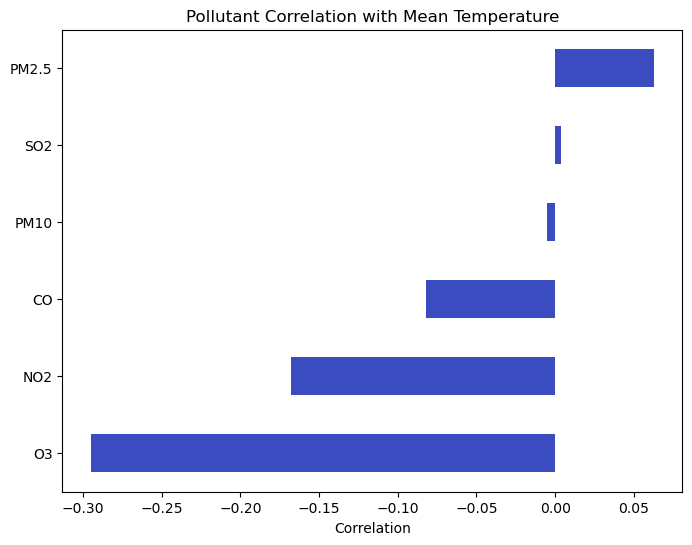

In [31]:
corr_vals = df_corr.corr()['Mean Temp (°C)'][pollutants]

corr_vals.sort_values().plot(
    kind='barh',
    figsize=(8,6),
    colormap='coolwarm'
)

plt.title('Pollutant Correlation with Mean Temperature')
plt.xlabel('Correlation')
plt.show()

In [29]:
temp_vars = ['Mean Temp (°C)', 'Max Temp (°C)', 'Min Temp (°C)']
precip_vars = ['Total Rain (mm)', 'Total Snow (cm)', 'Total Precip (mm)']
wind_vars = ['Spd of Max Gust (km/h)', 'wind_sin', 'wind_cos']

pollutants = ['CO', 'NO2', 'O3', 'PM10', 'PM2.5', 'SO2']

In [30]:
import numpy as np

# Store averaged correlations
temp_poll_corr = []
precip_poll_corr = []
wind_poll_corr = []

for prov, corr in province_corr.items():
    
    temp_poll_corr.append(corr.loc[temp_vars, pollutants])
    precip_poll_corr.append(corr.loc[precip_vars, pollutants])
    wind_poll_corr.append(corr.loc[wind_vars, pollutants])

# Average across provinces
temp_poll_avg = np.mean(temp_poll_corr, axis=0)
precip_poll_avg = np.mean(precip_poll_corr, axis=0)
wind_poll_avg = np.mean(wind_poll_corr, axis=0)

C:\Users\biauser\anaconda3\envs\ds312\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\biauser\anaconda3\envs\ds312\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [31]:
df = temp.merge(precip, on=['Date', 'Climate_ID'], how='inner') \
         .merge(wind, on=['Date', 'Climate_ID'], how='inner') \
         .merge(poll_pivot, on=['Date', 'Climate_ID'], how='inner')


In [32]:
df = df.merge(
    st[['Climate ID', 'Province']],
    left_on='Climate_ID',
    right_on='Climate ID',
    how='left'
)

df.drop(columns=['Climate ID'], inplace=True)

In [33]:
# Fill precip NaNs as 0
df[['Total Rain (mm)', 'Total Snow (cm)', 'Total Precip (mm)']] = \
    df[['Total Rain (mm)', 'Total Snow (cm)', 'Total Precip (mm)']].fillna(0)

# Drop rows with too many missing pollutant values
df = df.dropna(subset=['CO', 'NO2', 'O3', 'PM10', 'PM2.5', 'SO2'], how='all')

In [34]:
import numpy as np

df['wind_sin'] = np.sin(np.deg2rad(df['Dir of Max Gust (10s deg)']))
df['wind_cos'] = np.cos(np.deg2rad(df['Dir of Max Gust (10s deg)']))


In [35]:
province_corr = {}

for prov in df['Province'].dropna().unique():
    sub = df[df['Province'] == prov]
    
    # Only numeric columns
    corr = sub.corr(numeric_only=True)
    
    province_corr[prov] = corr


In [36]:
temp_vars = ['Mean Temp (°C)', 'Max Temp (°C)', 'Min Temp (°C)']
precip_vars = ['Total Rain (mm)', 'Total Snow (cm)', 'Total Precip (mm)']
wind_vars = ['Spd of Max Gust (km/h)', 'wind_sin', 'wind_cos']

pollutants = ['CO', 'NO2', 'O3', 'PM10', 'PM2.5', 'SO2']

In [37]:
temp_prov = {}
precip_prov = {}
wind_prov = {}

for prov, corr in province_corr.items():
    
    # Handle missing safely
    available_pollutants = [p for p in pollutants if p in corr.columns]
    
    temp_prov[prov] = corr.loc[temp_vars, available_pollutants]
    precip_prov[prov] = corr.loc[precip_vars, available_pollutants]
    wind_prov[prov] = corr.loc[wind_vars, available_pollutants]

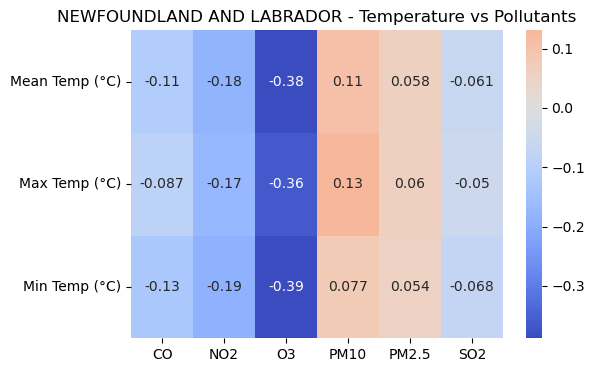

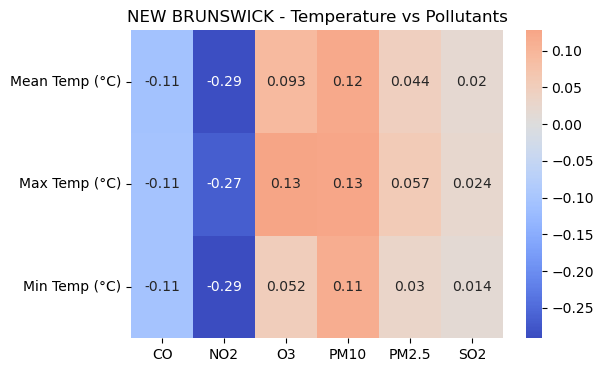

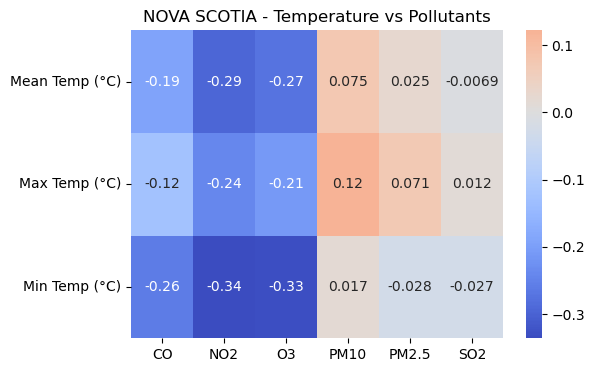

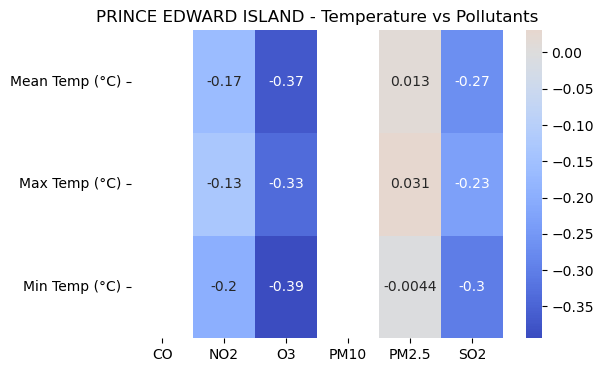

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

for prov, mat in temp_prov.items():
    plt.figure(figsize=(6,4))
    sns.heatmap(mat, annot=True, cmap='coolwarm', center=0)
    plt.title(f"{prov} - Temperature vs Pollutants")
    plt.show()

In [39]:
df['from_NE'] = df['Dir of Max Gust (10s deg)'].between(30, 100)

In [40]:
df.groupby('Province')['from_NE'].mean()

Province
NEW BRUNSWICK                0.466829
NEWFOUNDLAND AND LABRADOR    0.205963
NOVA SCOTIA                  0.234189
PRINCE EDWARD ISLAND         0.219775
Name: from_NE, dtype: float64

In [41]:
df['month'] = df['Date'].dt.month

# Spring + Summer = Mar–Aug
spring_summer = df[df['month'].between(3, 8)]

In [42]:
spring_summer['from_NE'] = spring_summer['Dir of Max Gust (10s deg)'].between(30, 100)

In [43]:
spring_summer.groupby('Province')['from_NE'].mean()

Province
NEW BRUNSWICK                0.440489
NEWFOUNDLAND AND LABRADOR    0.192861
NOVA SCOTIA                  0.203476
PRINCE EDWARD ISLAND         0.184177
Name: from_NE, dtype: float64

In [44]:
ss_nf = spring_summer[spring_summer['Province'] == 'NEWFOUNDLAND AND LABRADOR']
ss_nb = spring_summer[spring_summer['Province'] == 'NEW BRUNSWICK']

print("NF NE wind:", ss_nf['from_NE'].mean())
print("NB NE wind:", ss_nb['from_NE'].mean())

NF NE wind: 0.19286104534693135
NB NE wind: 0.440488895542281


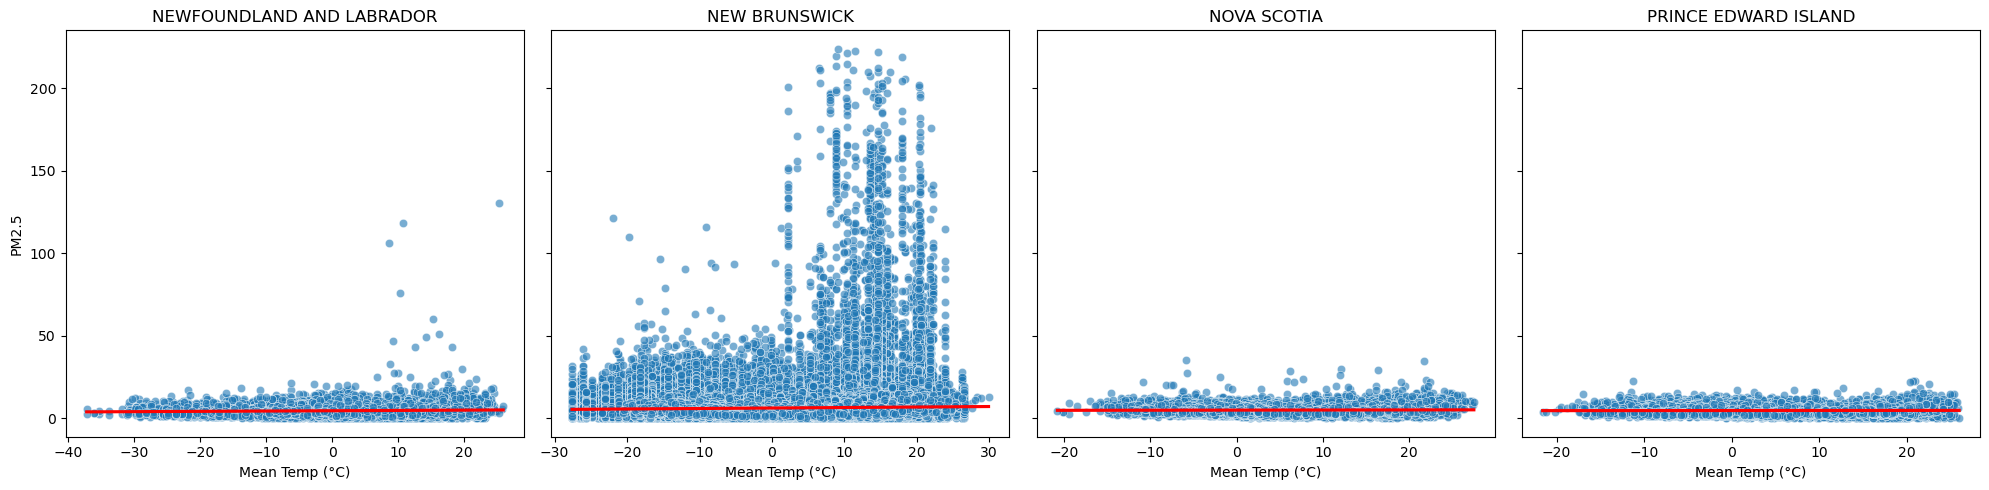

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

provinces = [
    'NEWFOUNDLAND AND LABRADOR',
    'NEW BRUNSWICK',
    'NOVA SCOTIA',
    'PRINCE EDWARD ISLAND'
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for i, prov in enumerate(provinces):
    
    sub = df[df['Province'] == prov]
    
    sns.scatterplot(
        data=sub,
        x='Mean Temp (°C)',
        y='PM2.5',
        ax=axes[i],
        alpha=0.6
    )
    
    # Add regression line (important)
    sns.regplot(
        data=sub,
        x='Mean Temp (°C)',
        y='PM2.5',
        ax=axes[i],
        scatter=False,
        color='red'
    )
    
    axes[i].set_title(prov)
    axes[i].set_xlabel("Mean Temp (°C)")
    
axes[0].set_ylabel("PM2.5")

plt.tight_layout()
plt.show()


In [46]:
def get_season(month):
    if month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Fall'
    else:
        return 'Winter'

df['season'] = df['Date'].dt.month.apply(get_season)

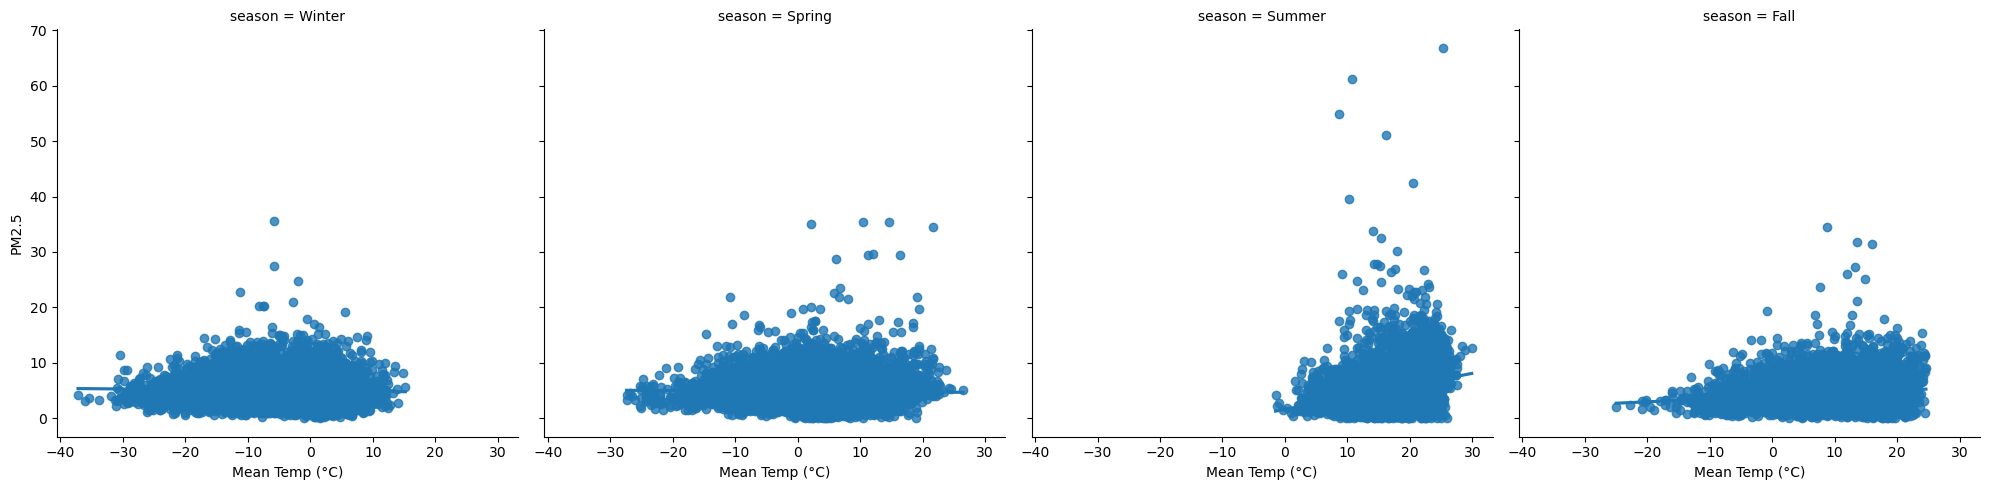

In [51]:
sns.lmplot(x='Mean Temp (°C)', y='PM2.5', data=df, col='season')

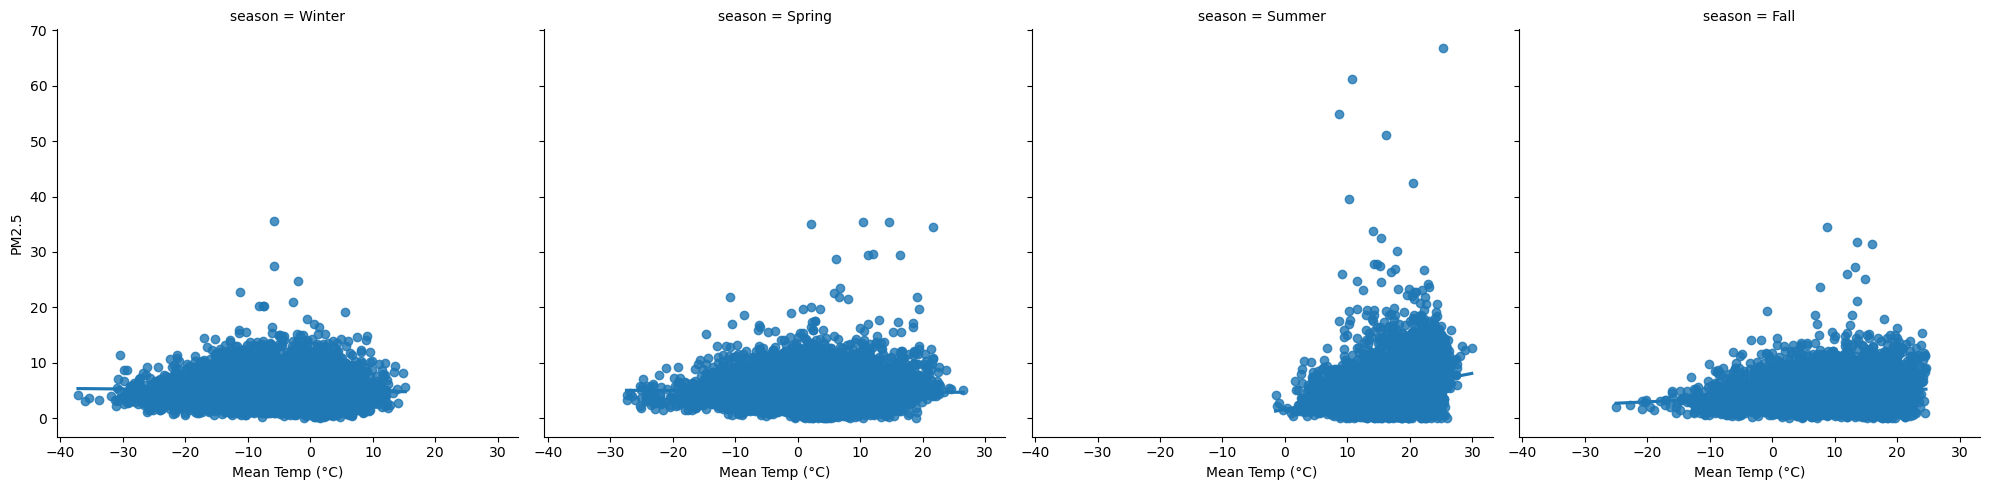

In [52]:
sns.lmplot(
    x='Mean Temp (°C)',
    y='PM2.5',
    data=df,
    col='season',
    col_order=['Winter', 'Spring', 'Summer', 'Fall']
)

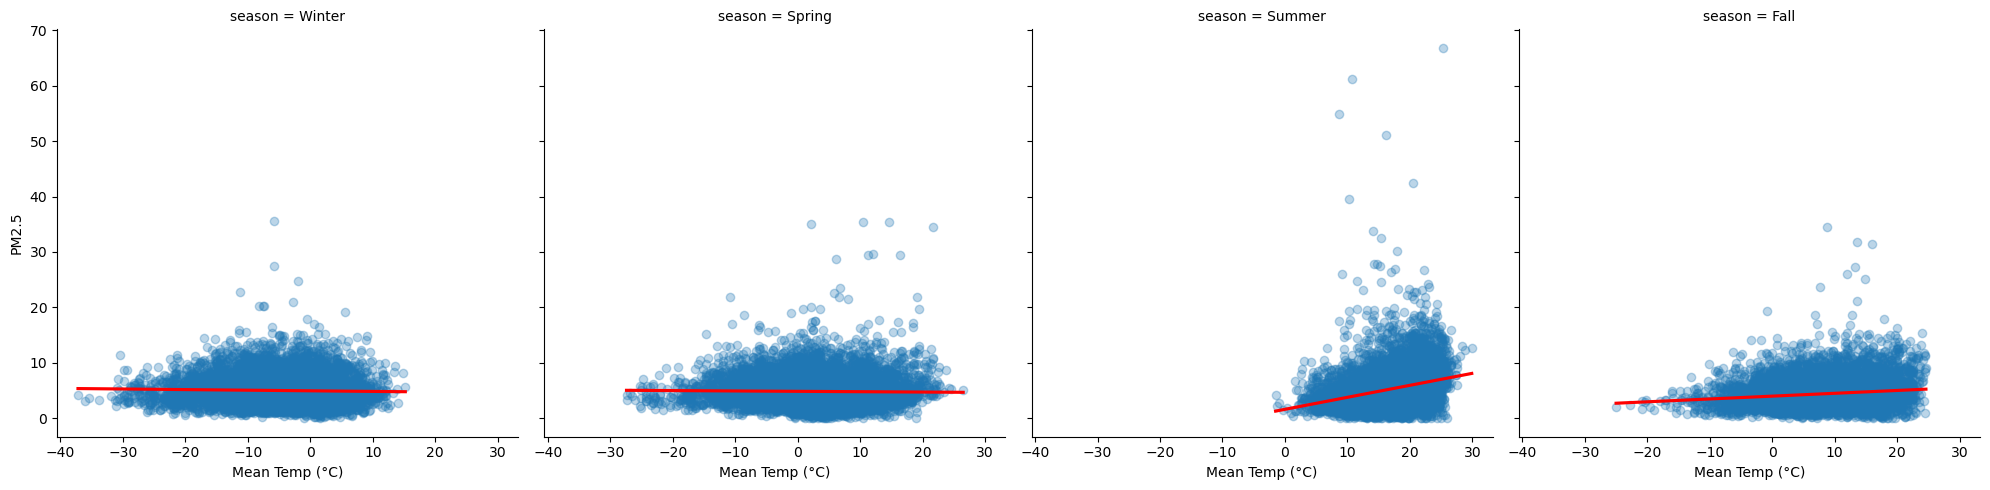

In [53]:
sns.lmplot(
    x='Mean Temp (°C)',
    y='PM2.5',
    data=df,
    col='season',
    col_order=['Winter', 'Spring', 'Summer', 'Fall'],
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

In [54]:
ss = df[df['season'].isin(['Spring', 'Summer'])]

In [55]:
temp_var = 'Mean Temp (°C)'

pollutants = ['PM2.5', 'PM10', 'NO2', 'CO', 'O3', 'SO2']

In [57]:
corr_vals = ss[[temp_var] + pollutants].corr()

# Extract only temp vs pollutants
temp_corr = corr_vals.loc[temp_var, pollutants]

print(temp_corr.sort_values(ascending=False))

PM2.5    0.125512
SO2      0.002498
PM10    -0.036893
CO      -0.103965
NO2     -0.197379
O3      -0.436065
Name: Mean Temp (°C), dtype: float64


C:\Users\biauser\AppData\Local\Temp\ipykernel_6324\1447328533.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=temp_corr.values, y=temp_corr.index, palette='coolwarm')


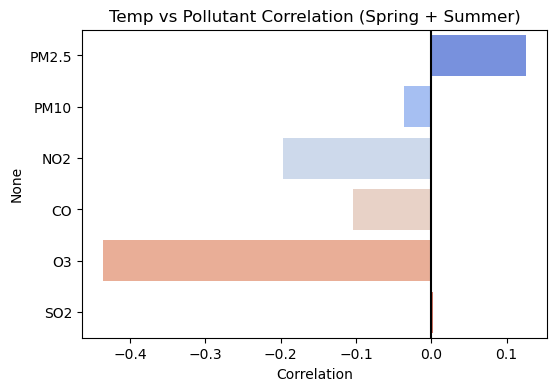

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.barplot(x=temp_corr.values, y=temp_corr.index, palette='coolwarm')
plt.axvline(0, color='black')
plt.title("Temp vs Pollutant Correlation (Spring + Summer)")
plt.xlabel("Correlation")
plt.show()

In [59]:
Q1 = df['PM2.5'].quantile(0.25)
Q3 = df['PM2.5'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['PM2.5'] < lower) | (df['PM2.5'] > upper)]

print("Number of outliers:", len(outliers))
outliers.head()


Number of outliers: 1332


,Climate_ID,Date,Max Temp (°C),Min Temp (°C),Mean Temp (°C),Heat Deg Days (°C),Cool Deg Days (°C),Total Rain (mm),Total Snow (cm),Total Precip (mm),...,O3,PM10,PM2.5,SO2,Province,wind_sin,wind_cos,from_NE,month,season
7,8400301,2015-01-13,-6.4,-26.6,-16.5,34.5,0.0,0.0,0.0,0.0,...,0.034375,NaN,12.916667,0.9,NEWFOUNDLAND AND LABRADOR,0.544639,0.838671,True,1,Winter
95,8400301,2015-05-26,26.5,4.5,15.5,2.5,0.0,0.0,0.0,5.6,...,0.056375,NaN,10.375000,0.4,NEWFOUNDLAND AND LABRADOR,0.374607,0.927184,False,5,Spring
138,8400301,2015-08-18,31.6,13.5,22.6,0.0,4.6,0.0,0.0,0.0,...,0.037375,NaN,11.250000,0.7,NEWFOUNDLAND AND LABRADOR,0.406737,0.913545,False,8,Summer
193,8400301,2015-12-03,3.2,-6.3,-1.6,19.6,0.0,0.0,0.0,11.7,...,0.034125,NaN,10.666667,0.5,NEWFOUNDLAND AND LABRADOR,0.087156,0.996195,False,12,Winter
342,8400301,2016-09-13,24.2,6.2,15.2,2.8,0.0,0.0,0.0,0.0,...,0.027500,NaN,10.454545,6.0,NEWFOUNDLAND AND LABRADOR,0.406737,0.913545,False,9,Fall


In [60]:
outliers_season = {}

for s in df['season'].unique():
    sub = df[df['season'] == s]
    
    Q1 = sub['PM2.5'].quantile(0.25)
    Q3 = sub['PM2.5'].quantile(0.75)
    IQR = Q3 - Q1
    
    upper = Q3 + 1.5 * IQR
    
    outliers_season[s] = sub[sub['PM2.5'] > upper]

# Example:
outliers_season['Summer'].head()


,Climate_ID,Date,Max Temp (°C),Min Temp (°C),Mean Temp (°C),Heat Deg Days (°C),Cool Deg Days (°C),Total Rain (mm),Total Snow (cm),Total Precip (mm),...,O3,PM10,PM2.5,SO2,Province,wind_sin,wind_cos,from_NE,month,season
514,8400301,2017-08-22,28.2,9.9,19.1,0.0,1.1,0.0,0.0,0.0,...,0.033625,NaN,14.521739,0.5,NEWFOUNDLAND AND LABRADOR,0.390731,0.920505,False,8,Summer
1638,8400301,2024-06-19,32.4,10.6,21.5,0.0,3.5,0.0,0.0,0.0,...,0.037250,NaN,11.615385,NaN,NEWFOUNDLAND AND LABRADOR,0.406737,0.913545,False,6,Summer
1639,8400301,2024-06-20,33.0,13.4,23.2,0.0,5.2,0.0,0.0,0.0,...,0.036875,75.583333,13.875000,NaN,NEWFOUNDLAND AND LABRADOR,0.484810,0.874620,False,6,Summer
1642,8400301,2024-06-23,27.9,3.6,15.7,2.3,0.0,0.0,0.0,1.2,...,0.036250,44.375000,11.375000,NaN,NEWFOUNDLAND AND LABRADOR,0.390731,0.920505,False,6,Summer
1656,8400301,2024-07-28,30.2,8.2,19.2,0.0,1.2,0.0,0.0,0.0,...,0.027875,55.500000,12.291667,NaN,NEWFOUNDLAND AND LABRADOR,0.453990,0.891007,False,7,Summer


In [61]:
from scipy.stats import zscore

df['z_PM25'] = zscore(df['PM2.5'])

outliers_z = df[df['z_PM25'].abs() > 3]

<Axes: xlabel='season', ylabel='PM2.5'>

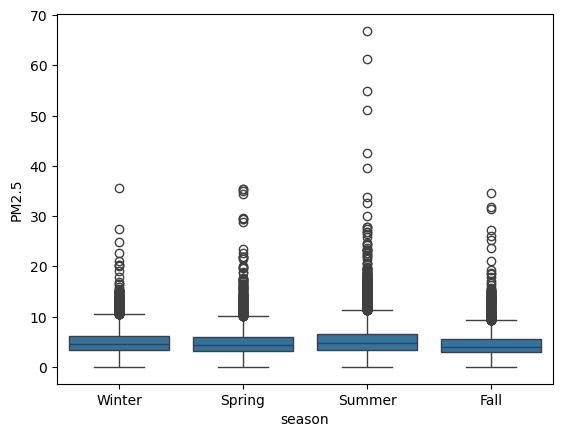

In [62]:
import seaborn as sns

sns.boxplot(x='season', y='PM2.5', data=df)

<Axes: xlabel='Mean Temp (°C)', ylabel='PM2.5'>

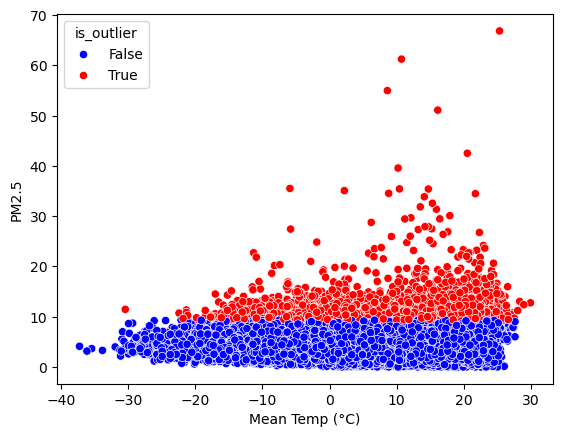

In [63]:
df['is_outlier'] = df['PM2.5'] > upper  # from IQR earlier

sns.scatterplot(
    data=df,
    x='Mean Temp (°C)',
    y='PM2.5',
    hue='is_outlier',
    palette={True: 'red', False: 'blue'}
)

In [64]:
outliers[['Date', 'Province', 'PM2.5', 'Mean Temp (°C)']].head()

,Date,Province,PM2.5,Mean Temp (°C)
7,2015-01-13,NEWFOUNDLAND AND LABRADOR,12.916667,-16.5
95,2015-05-26,NEWFOUNDLAND AND LABRADOR,10.375000,15.5
138,2015-08-18,NEWFOUNDLAND AND LABRADOR,11.250000,22.6
193,2015-12-03,NEWFOUNDLAND AND LABRADOR,10.666667,-1.6
342,2016-09-13,NEWFOUNDLAND AND LABRADOR,10.454545,15.2


In [65]:
outliers[['PM2.5', 'Spd of Max Gust (km/h)', 'Total Precip (mm)']].describe()

,PM2.5,Spd of Max Gust (km/h),Total Precip (mm)
count,1332.000000,1332.000000,1332.000000
mean,13.237594,46.498498,3.099850
std,4.420977,15.038568,7.441846
min,10.357137,28.000000,0.000000
25%,11.041667,35.000000,0.000000
50%,11.916667,42.000000,0.000000
75%,13.752604,54.000000,2.200000
max,66.833333,149.000000,75.000000


In [69]:
high_pollution = df[df['PM2.5'] > 35]

high_pollution[['Date', 'Province', 'PM2.5', 
                'Mean Temp (°C)', 
                'Spd of Max Gust (km/h)',
                'Total Precip (mm)']].head()


,Date,Province,PM2.5,Mean Temp (°C),Spd of Max Gust (km/h),Total Precip (mm)
10917,2018-08-15,NEW BRUNSWICK,42.500619,20.5,53.0,52.6
11620,2023-05-17,NEW BRUNSWICK,35.066667,2.2,44.0,0.0
11623,2023-05-20,NEW BRUNSWICK,35.386960,14.7,32.0,4.0
11624,2023-05-21,NEW BRUNSWICK,35.410168,10.4,46.0,12.3
45682,2015-02-15,NOVA SCOTIA,35.500000,-5.9,100.0,19.2


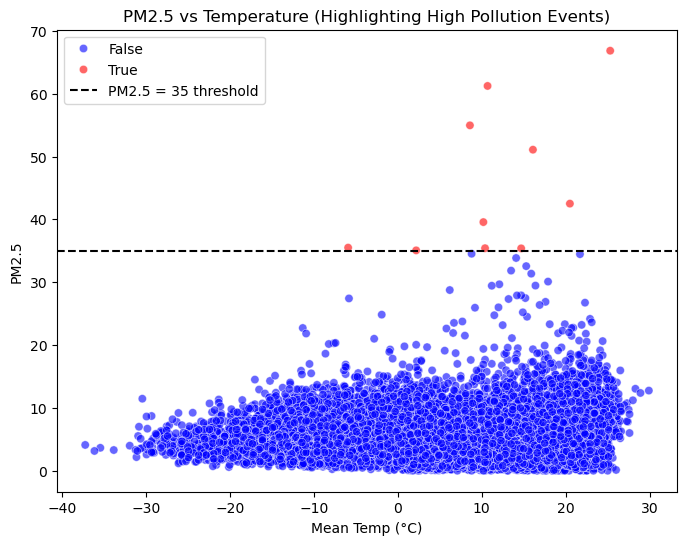

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

df['high_pollution'] = df['PM2.5'] > 35

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Mean Temp (°C)',
    y='PM2.5',
    hue='high_pollution',
    palette={True: 'red', False: 'blue'},
    alpha=0.6
)

plt.axhline(35, color='black', linestyle='--', label='PM2.5 = 35 threshold')

plt.title("PM2.5 vs Temperature (Highlighting High Pollution Events)")
plt.legend()
plt.show()

In [71]:
print(naps.columns)

Index(['NAPS_ID', 'Station_Name', 'City', 'Province/Territory_EN',
       'Province_Code', 'Latitude', 'Longitude', 'Status', 'Start_Date',
       'End_Date'],
      dtype='str')


In [74]:
print(df.columns)


Index(['Climate_ID', 'Date', 'Max Temp (°C)', 'Min Temp (°C)',
       'Mean Temp (°C)', 'Heat Deg Days (°C)', 'Cool Deg Days (°C)',
       'Total Rain (mm)', 'Total Snow (cm)', 'Total Precip (mm)',
       'Snow on Grnd (cm)', 'wind_key', 'Dir of Max Gust (10s deg)',
       'Spd of Max Gust (km/h)', 'CO', 'NO2', 'O3', 'PM10', 'PM2.5', 'SO2',
       'Province', 'wind_sin', 'wind_cos', 'from_NE', 'month', 'season',
       'z_PM25', 'is_outlier', 'high_pollution'],
      dtype='str')


In [75]:
print(poll_pivot.columns)

Index(['Date', 'Climate_ID', 'CO', 'NO2', 'O3', 'PM10', 'PM2.5', 'SO2'], dtype='str', name='Pollutant')


In [73]:
df = df.merge(
    naps[['NAPS_ID', 'Station_Name', 'City']],
    on='NAPS_ID',
    how='left'
)

KeyError: 'NAPS_ID'